In [1]:
# Exercises for laboratory work


# Import of modules
import numpy as np
from scipy.fftpack import dct


def split_meta_line(line, delimiter=' '):
    # First you need to prepare split_meta_line function for meta line parsing
    # line format is "Speaker_ID Gender Path"
    
    """
    :param line: lines of metadata
    :param delimiter: delimeter
    :return: speaker_id: speaker IDs: gender: gender: file_path: path to file
    """

    ###########################################################
    # Here is your code
    speaker_id, gender, file_path = line.split(delimiter)
    file_path = re.sub('\n', '', file_path)
    ###########################################################

    return speaker_id, gender, file_path

def preemphasis(signal, pre_emphasis=0.97):
    #Here you need to preemphasis input signal with pre_emphasis coeffitient

    """
    :param signal: input signal
    :param pre_emphasis: preemphasis coeffitient
    :return: emphasized_signal: signal after pre-emphasis procedure
    """

    ###########################################################
    # Here is your code
    emphasized_signal = [signal[0]]
    for i in range(1, len(signal)):
        emphasized_signal.append(signal[i] - 0.97 * signal[i-1])
    ###########################################################

    return emphasized_signal

def framing(emphasized_signal, sample_rate=16000, frame_size=0.025, frame_stride=0.01):
    # Here you need to perform framing of the input signal emphasized_signal with sample rate sample_rate
    # Please use hamming windowing
    
    """
    :param emphasized_signal: signal after pre-emphasis procedure
    :param sample_rate: signal sampling rate
    :param frame_size: sliding window size
    :param frame_stride: step
    :return: frames: output matrix [nframes x sample_rate*frame_size]
    """

    frame_length, frame_step = frame_size * sample_rate, frame_stride * sample_rate # convert from seconds to samples
    signal_length = len(emphasized_signal)
    frame_length = int(round(frame_length))
    frame_step = int(round(frame_step))
    num_frames = int(
        np.ceil(float(np.abs(signal_length - frame_length)) / frame_step)) # make sure that we have at least 1 frame

    pad_signal_length = num_frames * frame_step + frame_length
    z = np.zeros((pad_signal_length - signal_length))
    pad_signal = np.append(emphasized_signal, z) # pad Signal to make sure that all frames have equal number of samples without
                                                 # truncating any samples from the original signal

    ###########################################################
    # Here is your code to compute frames
    frames = []
    start_idx = 0
    end_idx = frame_length
    index = [[start_idx]]
    while end_idx != len(pad_signal):
        frames.append(pad_signal[start_idx:end_idx])
        start_idx += frame_step
        end_idx += frame_step
    frames = np.hamming(frame_length) * frames
    ###########################################################

    return frames

def power_spectrum(frames, NFFT=512):
    # Here you need to compute power spectum of framed signal with NFFT fft bins number

    """
    :param frames: framed signal
    :param NFFT: number of fft bins
    :return: pow_frames: framed signal power spectrum
    """

    mag_frames = np.absolute(np.fft.rfft(frames, NFFT))  # Magnitude of the FFT

    ###########################################################
    # Here is your code to compute pow_frames
    pow_frames = ((1.0 / NFFT) * np.power(mag_frames,2)) 
    ###########################################################

    return pow_frames

def compute_fbank_filters(nfilt=40, sample_rate=16000, NFFT=512):
    # Here you need to compute fbank filters (FBs) for special case (sample_rate & NFFT)

    """
    :param nfilt: number of filters
    :param sample_rate: signal sampling rate
    :param NFFT: number of fft bins in power spectrum
    :return: fbank [nfilt x (NFFT/2+1)]
    """
    
    low_freq_mel = 0
    high_freq = sample_rate / 2

    ###########################################################
    # Here is your code to convert Convert Hz to Mel: 
    # high_freq -> high_freq_mel
    high_freq_mel = 2595.0 * np.log10(1 + high_freq / 700)
    ###########################################################

    mel_points = np.linspace(low_freq_mel, high_freq_mel, nfilt + 2) # equally spaced in mel scale

    ###########################################################
    # Here is your code to convert Convert Mel to Hz: 
    # mel_points -> hz_points
    hz_points = 700.0 * (10 ** (mel_points / 2595.0) - 1)
    ###########################################################

    bin = np.floor((NFFT + 1) * hz_points / sample_rate)

    fbank = np.zeros((nfilt, int(np.floor(NFFT / 2 + 1))))
    for m in range(1, nfilt + 1):
        f_m_minus = int(bin[m - 1]) # left
        f_m = int(bin[m])           # center
        f_m_plus = int(bin[m + 1])  # right

        for k in range(f_m_minus, f_m):
            fbank[m - 1, k] = (k - bin[m - 1]) / (bin[m] - bin[m - 1])
        for k in range(f_m, f_m_plus):
            fbank[m - 1, k] = (bin[m + 1] - k) / (bin[m + 1] - bin[m])

    return fbank

def compute_fbanks_features(pow_frames, fbank):
    # You need to compute fbank features using power spectrum frames and suitable fbanks filters
    
    """
    :param pow_frames: framed signal power spectrum, matrix [nframes x sample_rate*frame_size]
    :param fbank: matrix of the fbank filters [nfilt x (NFFT/2+1)] where NFFT: number of fft bins in power spectrum
    :return: filter_banks_features: log mel FB energies matrix [nframes x nfilt]
    """
    
    ###########################################################
    # Here is your code to compute filter_banks_features
    filter_banks_features = np.dot(pow_frames, fbank.T)
    ###########################################################

    filter_banks_features = np.where(filter_banks_features == 0, np.finfo(float).eps,
                                     filter_banks_features) # numerical stability
    filter_banks_features = np.log(filter_banks_features) ### 20 * ?

    return filter_banks_features

def compute_mfcc(filter_banks_features, num_ceps=20):
    # Here you need to compute MFCCs features using precomputed log mel FB energies matrix
    
    """
    :param filter_banks_features: log mel FB energies matrix [nframes x nfilt]
    :param num_ceps: number of cepstral components for MFCCs
    :return: mfcc: mel-frequency cepstral coefficients (MFCCs)
    """
    
    ###########################################################
    # Here is your code to compute mfcc features
    mfcc = dct(filter_banks_features, 2, filter_banks_features.shape[1], 1, "ortho")[:,1:(num_ceps+1)]
    ###########################################################

    return mfcc

def mvn_floating(features, LC, RC, unbiased=False):
    # Here you need to do mean variance normalization of the input features
    
    """
    :param features: features matrix [nframes x nfeats]
    :param LC: the number of frames to the left defining the floating
    :param RC: the number of frames to the right defining the floating
    :param unbiased: biased or unbiased estimation of normalising sigma
    :return: normalised_features: normalised features matrix [nframes x nfeats]
    """
    
    nframes, dim = features.shape
    LC = min(LC, nframes - 1)
    RC = min(RC, nframes - 1)
    n = (np.r_[np.arange(RC + 1, nframes), np.ones(RC + 1) * nframes] - np.r_[np.zeros(LC), np.arange(nframes - LC)])[:,
        np.newaxis]
    f = np.cumsum(features, 0)
    s = np.cumsum(features ** 2, 0)
    f = (np.r_[f[RC:], np.repeat(f[[-1]], RC, axis=0)] - np.r_[np.zeros((LC + 1, dim)), f[:-LC - 1]]) / n
    s = (np.r_[s[RC:], np.repeat(s[[-1]], RC, axis=0)] - np.r_[np.zeros((LC + 1, dim)), s[:-LC - 1]]
         ) / (n - 1 if unbiased else n) - f ** 2 * (n / (n - 1) if unbiased else 1)
    
    ###########################################################
    # Here is your code to compute normalised features
    normalised_features = (features - f) / np.sqrt(s)
    ###########################################################

    normalised_features[s == 0] = 0

    return normalised_features

Лабораторный практикум по курсу «Распознавание диктора», Университет ИТМО, 2021

Лабораторная работа №1. Информативные признаки речевых сигналов: извлечение признаков

Цель работы: изучение процедуры построения информативных акустических признаков для речевых сигналов.

Краткое описание: в рамках настоящей лабораторной работы требуется познакомиться с процедурами предобработки речевых сигналов и извлечения информативных признаков. В работе предлагается научиться извлекать кратковременные энергии мел-частотных полос (MFBs, mel filter banks) и мел-частотные кепстральные коэффициенты (MFCCs, mel frequency cepstral coeffitients).

Данные: в качестве данных для выполнения лабораторной работы предлагается использовать тестовую часть базы VoxCeleb1.

Содержание лабораторной работы

Подготовка данных для анализа.

Выполнение процедуры высокочастотной фильтрации (преэмфазис) речевого сигнала.

Вычисление акустических признаков разных видов.

Выполнение локальных центрирования и масштабирования акустических признаков.

Построение распределений первых трёх компонент полученных акустических признаков для мужских и женских голосов.

In [2]:
# IPython extension to reload modules before executing user code
%load_ext autoreload
%autoreload 2

# Import of modules
import os
import sys

sys.path.append(os.path.realpath('..'))

# from common import download_dataset, extract_dataset

from math import sqrt, pi
from scipy.fftpack import dct
import re
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import hist, plot, show, grid, title, xlabel, ylabel, legend, axis, imshow

from mpl_toolkits.axes_grid1 import make_axes_locatable

from skimage.morphology import opening, closing
from torchaudio.transforms import Resample
from multiprocessing import Pool
import torchaudio

2. Выполнение процедуры высокочастотной фильтрации (преэмфазис) речевого сигнала

В рамках настоящего пункта предлагается изучить процедуру предобработки речевых сигналов, получившую название преэмфазис. Преэмфазис (pre-emphasis) – применение фильтра верхних частот к сигналу до процедуры извлечения признаков для того, чтобы компенсировать тот факт, что обычно вокализованная речь содержит на низких частотах намного больше энергии, чем невокализованная речь на высоких. Обозначим через  обрабатываемый сигнал, а через  результат обработки, тогда процедура преэмфазиса может быть описана с помощью следующего выражения:

Выражение выше представляет собой линейное разностное уравнение с постоянными коэффициентами и позволяет описать процедуру работы нерекурсивного фильтра первого порядка с конечной импульсной характеристикой. Параметр  является единственным параметром рассматриваемого фильтра. В случае, когда параметр  является отрицательным, рассматриваемый фильтр обладает свойствами фильтра верхних частот. Для выполнения процедуры преэмфазиса обычно параметр .

В рамках настоящего пункта требуется:

Загрузить анализируемый речевой сигнал.

Выполнить процедуру преэмфазиса по отношению к загруженному речевому сигналу.

Сравнить спектры речевых сигналов до и после процедуры преэмфазиса.

2.1. Загрузка файла. Осцилограмма. Спектрограмма. Для начала, давайте, загрузим пример речевого сигнала в память компьютера. Сейчас существует достаточно много библиотек для работы со звуковыми файлами (scipy.io.wavfile, soundfile, torchaudio и т.п.). Можно использовать любую из них для работы. Мы остановим свой выбор на torchaudio для удобства и системности дальнейшего изложения. В папке ./metadata/ представлен файл meta.txt со списком файлов, которые мы предлагаем использовать в данной лабораторной работе. Файл meta.txt имеет достаточно простой формат строк:
```
Speaker_ID Gender Path
id10271 m ../data/voxceleb1_test/wav/id10271/1gtz-CUIygI/00006.wav
id10272 m ../data/voxceleb1_test/wav/id10272/dkN2DIBrXqQ/00008.wav
id10273 m ../data/voxceleb1_test/wav/id10273/8cfyJEV7hP8/00002.wav
...
```

Распарсим файл с метаинформацией и загрузим первый по списку файл

In [3]:
path_to_meta = "../input/metadata-lab1-speakeridentification/metadata.txt"

p = Pool(1)
with open(path_to_meta, 'r') as f:
     list_lines = f.readlines()
speaker_ids, genders, paths = zip(*p.map(split_meta_line, list_lines[1:]))

path_to_wav = paths[0]

In [4]:
print("Loading of {}".format(path_to_wav))

# Load signal
signal, sample_rate = torchaudio.load(path_to_wav)
signal = signal.numpy().squeeze(axis=0)
signal = signal/np.abs(signal).max()

print("Done!")

Loading of ../input/voxceleb/vox1_test_wav/wav/id10271/1gtz-CUIygI/00006.wav
Done!


Построим осцилограмму и спектрограмму первых 3.5 секунд речевого сигнала.

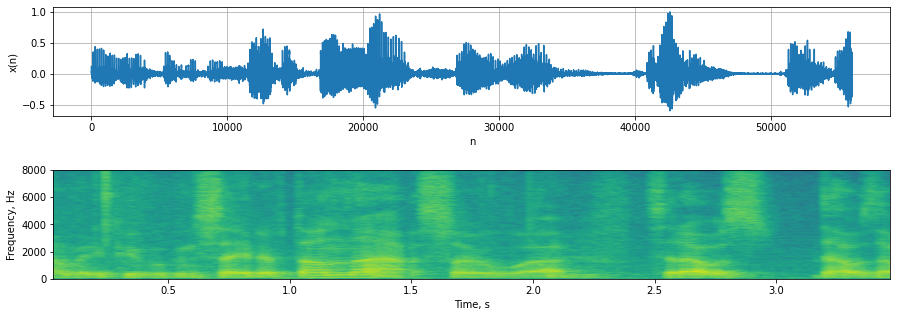

In [5]:
signal = signal[0:int(3.5 * sample_rate)]  # keep the first 3.5 seconds

plt.figure(1, figsize=(15, 5))
plot_a = plt.subplot(211)
plt.subplots_adjust(wspace=0, hspace=0.5)

plot_a.plot(signal)
plot_a.set_xlabel('n')
plot_a.set_ylabel('x(n)')
plot_a.grid()

plot_b = plt.subplot(212)
plot_b.specgram(signal, NFFT=1024, Fs=sample_rate, noverlap=900)
plot_b.set_xlabel('Time, s')
plot_b.set_ylabel('Frequency, Hz')
plt.show()

2.2. Выполнение процедуры преэмфазиса по отношению к загруженному речевому сигналу. Сравнение спектров

In [6]:
emphasized_signal = preemphasis(signal)

Построим спектрограммы обработанного и «сырого» сигналов.

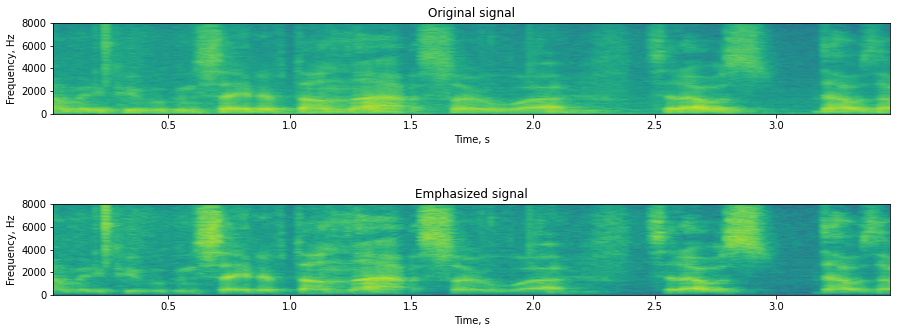

In [7]:
plt.figure(figsize=(15, 5))
plot_a = plt.subplot(211)
plt.subplots_adjust(wspace=0, hspace=1)

plot_a.specgram(signal, NFFT=1024, Fs=sample_rate, noverlap=900)
plot_a.set_xlabel('Time, s')
plot_a.set_ylabel('Frequency, Hz')
plot_a.title.set_text('Original signal')

plot_b = plt.subplot(212)
plot_b.specgram(emphasized_signal, NFFT=1024, Fs=sample_rate, noverlap=900)
plot_b.set_xlabel('Time, s')
plot_b.set_ylabel('Frequency, Hz')
plot_b.title.set_text('Emphasized signal')
plt.show()

3. Вычисление акустических признаков разных видов

Работа современных систем голосовой биометрии, как правило, является основанной на использовании акустических признаков. Акустические признаки являются формой представления речевого сигнала в частотно-временной области. Возможным примером акустических признаков является спектрограмма сигнала, которую можно вычислить с использованием оконного преобразования Фурье. Однако, использование спектрограммы на практике не является выгодным, в частности, из-за её большого разрешения по частоте. Поэтому возможным вариантом для построения акустических признаков могут являться: логарифмов энергий на выходе мел-банка фильтров, мел-частотные кепстральные коэффициенты размерности и т.п.

В рамках настоящего пункта предлагается вычислить логарифмы энергий на выходе мел-банка фильтров размерности 40 и мел-частотные кепстральные коэффициенты размерности 23. Для выполнения задания выше можно воспользоваться следующим алгоритмом:

Представить обрабатываемый речевой сигнал в виде набора фреймов с использованием окна Хэмминга (размер окна можно выбрать равным 25мс, а шаг окна – 10мс).

Вычислить одномерный спектр Фурье по отношению к каждому из фреймов.

Рассчитать мел-банк фильтров.

Перемножить квадрат амплитудно-частотной характеристики (АЧХ) каждого фильтра со спектром мощности каждого из фреймов ⁡и просуммировать коэффициенты получившихся спектров, рассчитав энергии внутри соответствующих полос банка фильтров.

Вычислить логарифм от значений энергий на предыдущем шаге. На этом шаге формируется первый тип акустических признаков.

Вычислить дискретное косинусное преобразование от логарифмов коэффициентов. На этом этапе формируются мел-частотные кепстральные коэффициенты.

Подробное описание процедуры вычисления акустических признаков можно найти по следующей ссылке.

3.1. Представление речевого сигнала в виде набора фреймов с использованием окна Хэмминга

In [8]:
frames = framing(emphasized_signal)

print("Features shape is: {}".format(frames.shape))

Features shape is: (348, 400)


Произведем расчет спектра мощности для каждого фрэйма.

In [9]:
pow_frames = power_spectrum(frames)

3.2. Рассчёт мел-банка фильтров

In [10]:
fbank = compute_fbank_filters(nfilt=40, sample_rate=16000, NFFT=512)

Построим квадраты АЧХ полученных фильтров.

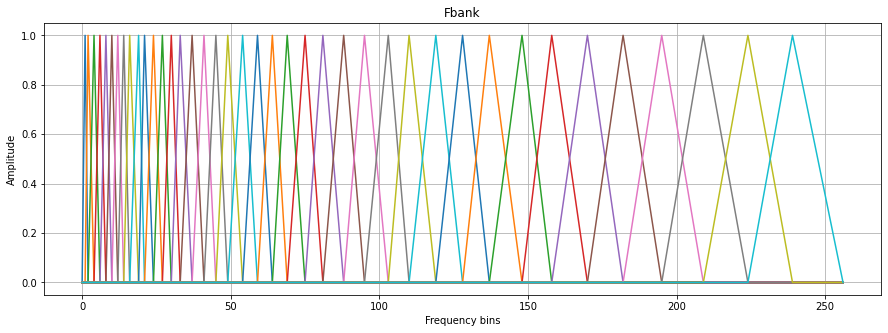

In [11]:
plt.figure(figsize=(15, 5))
plot_a = plt.subplot()
plt.subplots_adjust(wspace=0, hspace=1)

nfilt = fbank.shape[0]
for k in range(nfilt):
    plot_a.plot(fbank[k,:])
    
plot_a.set_xlabel('Frequency bins')
plot_a.set_ylabel('Amplitude')
plot_a.title.set_text('Fbank')
plot_a.grid()
plt.show()

3.3. Рассчёт энергии сигнала внутри соответствующих полос банка фильтров

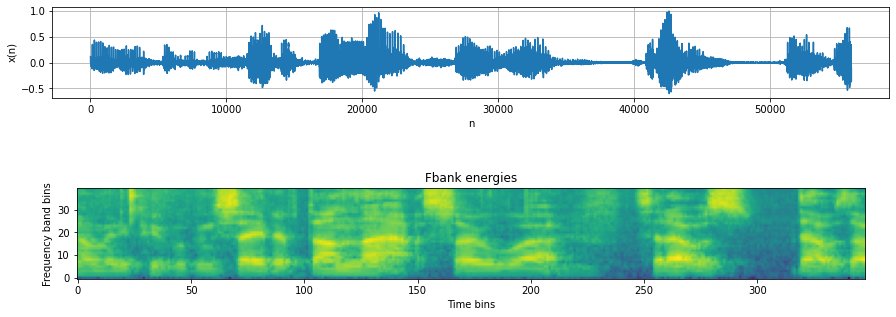

In [12]:
filter_banks_features = compute_fbanks_features(pow_frames, fbank)

plt.figure(3, figsize=(15, 5))
plt.subplots_adjust(wspace=0, hspace=1)

plot_a = plt.subplot(211)
plot_a.plot(signal)
plot_a.set_xlabel('n')
plot_a.set_ylabel('x(n)')
plot_a.grid()

plot_b = plt.subplot(212)
plot_b.imshow(filter_banks_features.T, origin='lower')

plot_b.set_xlabel('Time bins')
plot_b.set_ylabel('Frequency band bins')
plot_b.title.set_text('Fbank energies')
plt.show()

3.4. Вычисление дискретного косинусного преобразования от логарифмов энергий

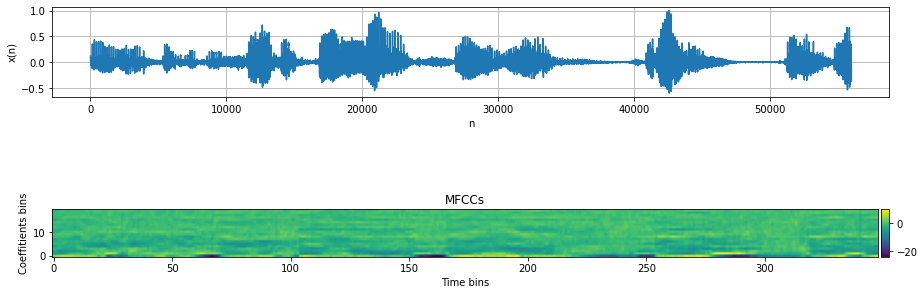

In [13]:
mfcc = compute_mfcc(filter_banks_features, num_ceps=20)

fig = plt.figure(figsize=(15, 5))
plt.subplots_adjust(wspace=0, hspace=1)
plot_a = plt.subplot(211)
plot_a.plot(signal)
plot_a.set_xlabel('n')
plot_a.set_ylabel('x(n)')
plot_a.grid()

plot_b = plt.subplot(212)
im = plot_b.imshow(mfcc.T, origin='lower')

divider = make_axes_locatable(plot_b)
cax = divider.append_axes("right", size="1%", pad=0.05)
plt.colorbar(im, cax=cax)

plot_b.set_xlabel('Time bins')
plot_b.set_ylabel('Coeffitients bins')
plot_b.title.set_text('MFCCs')
plt.show()

4. Выполнение локальных центрирования и масштабирования акустических признаков

Канал связи может вносит некоторое смещение в захваченный сигнал (микрофон может не иметь равномерную АЧХ, изменения в усилении сигнал приводят к вычислению различных акустических признаков даже для одного и того же куска речи). Канальный эффект можно промоделировать с использованием линейного инвариантного к сдвигу фильтра (ЛИС-фильтра) и учесть при корректировке значений акустических признаков. Данная процедура получила название процедуры нормализации.

Идея выполнения процедуры нормализации состоит в вычислении среднего вектора наблюдаемых акустических признаков и центрирования всех векторов акустических признаков произнесения на это среднее. Процедура нормализации может быть выполнена несколькими различными способами:

Локально по произнесению (вычисляем среднее в некоторой окрестности (обычно 300 фреймов) каждого фрейма стека признаков и нормализуем на них этот фрейм).

Глобально по произнесению (вычисляем среднее один раз по всей сессии и нормализуем на них все фреймы сессии).

глобально по базе данных (вычисляем среднее общее для всех сессий в тренировочной базе данных и нормализуем на них все фреймы всех сессий).

Иногда процедура нормализации сопровождается процедурой масштабирования акустических признаков. Процедура масштабирования признаков может быть выполнена теми же способами, что и процедура нормализации. Отличие процедуры масштабирования признаков от процедуры нормализации состоит в том, что при её выполнении необходимо вычислить не средний вектор акустических признаков, а вектор среднеквадратического отклонения, на который необходимо поэлементно разделить каждый нормализованный вектор акустических признаков некоторого произнесения.

Предполагая, что набор акустических признаков до выполнения процедур нормализации и масштабирования был задан функцией , а после выполнения данных процедур – , запишем следующее выражение:

 
где  – это средний вектор акустических признаков,  – это вектор среднеквадратического отклонения акустических признаков,  и  имеют суть частоты и времени ( – номер спектральной составляющей, а  – это номер фрейма).

В рамках настоящего пункта требуется выполнить процедуры нормализации и масштабирования по отношению к логарифмам энергий на выходе банка фильтров и мел-частотным кепстральным коэффициентам, вычисленным для некоторой звукозаписи.

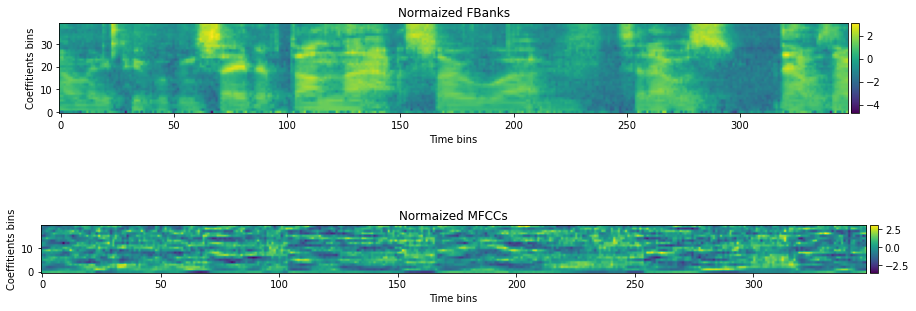

In [14]:
mfcc_cmvn = mvn_floating(mfcc, 150, 150)
filter_banks_features_mvn = mvn_floating(filter_banks_features, 150, 150)

fig = plt.figure(3, figsize=(15, 5))
plt.subplots_adjust(wspace=0, hspace=1)

plot_b = plt.subplot(211)
im_b = plot_b.imshow(filter_banks_features_mvn.T, origin='lower')
divider = make_axes_locatable(plot_b)
cax = divider.append_axes("right", size="1%", pad=0.05)
plt.colorbar(im_b, cax=cax)
plot_b.set_xlabel('Time bins')
plot_b.set_ylabel('Coeffitients bins')
plot_b.title.set_text('Normaized FBanks')

plot_с = plt.subplot(212)
im_c = plot_с.imshow(mfcc_cmvn.T, origin='lower')
divider = make_axes_locatable(plot_с)
cax = divider.append_axes("right", size="1%", pad=0.05)
plt.colorbar(im_c, cax=cax)
plot_с.set_xlabel('Time bins')
plot_с.set_ylabel('Coeffitients bins')
plot_с.title.set_text('Normaized MFCCs')
plt.show()

5. Построение распределений первых трёх компонент полученных акустических признаков для мужских и женских голосов

Для того, чтобы грубо проверить правильность расчёта акустических признаков выше, построим гистограммы распределения первых трёх компонент логарифмов энергий на выходе банка фильтров и мел-частотных кепстральных коэффициентов по некоторой базе данных. Рассмотрим в качестве этой базы звукозаписи мужских и женских голосов дикторов, список которых представлен в ./metadata/meta.txt. В указанном файле перечислен список из 20 звукозаписей (10 для дикторов женского пола и 10 для дикторов мужского пола) из базы VoxCeleb1 test set с указанием пути до них, идентификационного номера диктора и пола диктора (символ f означает женский пол, а символ m означает мужской пол).

Используя звукозаписи, список которых перечислен в ./metadata/meta.txt, выполнить построение гистограмм распределения первых 3 компонент логарифмов энергий на выходе банка фильтров и мел-частотных кепстральных коэффициентов отдельно для базы мужских и женских голосов.

(18908, 40)
(18604, 40)
(18908, 20)
(18604, 20)


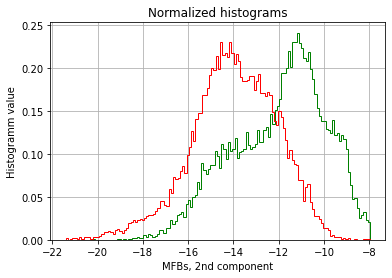

In [15]:
fbank = compute_fbank_filters(nfilt=40, sample_rate=16000, NFFT=512)

def compute_feats(signal):
    # Function to compute mel frequency cepstral coefficient
    
    emphasized_signal = preemphasis(signal)
    frames = framing(emphasized_signal)
    pow_frames = power_spectrum(frames)
    filter_banks_features = compute_fbanks_features(pow_frames, fbank)
    mfcc = compute_mfcc(filter_banks_features, num_ceps=20)
    
    # mfcc = mvn_floating(mfcc, 150, 150)
    # filter_banks_features = mvn_floating(filter_banks_features, 150, 150)
    
    return filter_banks_features, mfcc

male_fb_features = []
female_fb_features = []
male_mfcc_features = []
female_mfcc_features = []

for (path_to_wav, gender) in zip(paths, genders):
    # Load signal
    signal, sample_rate = torchaudio.load(path_to_wav)
    signal = signal.numpy().squeeze(axis=0)
    signal = signal/np.abs(signal).max()
    
    # Processing
    filter_banks_mvn, mfcc_cmvn = compute_feats(signal)
    if gender == 'm':
        male_fb_features.append(filter_banks_mvn)
        male_mfcc_features.append(mfcc_cmvn)
    else:
        female_fb_features.append(filter_banks_mvn) 
        female_mfcc_features.append(mfcc_cmvn)
    
male_fb_features = np.concatenate(male_fb_features)
print(male_fb_features.shape)

female_fb_features = np.concatenate(female_fb_features)
print(female_fb_features.shape)

male_mfcc_features = np.concatenate(male_mfcc_features)
print(male_mfcc_features.shape)

female_mfcc_features = np.concatenate(female_mfcc_features)
print(female_mfcc_features.shape)


comp_number = 1
coeff1_male = male_fb_features[:, comp_number]
coeff1_female = female_fb_features[:, comp_number]

min_coeff1 = min(coeff1_male.min(), coeff1_female.min())
max_coeff1 = min(coeff1_male.max(), coeff1_female.max())

hist(coeff1_male,   int(sqrt(len(coeff1_male))),   histtype='step', color='green', range=(min_coeff1, max_coeff1), density=1)
hist(coeff1_female, int(sqrt(len(coeff1_female))), histtype='step', color='red',   range=(min_coeff1, max_coeff1), density=1)
xlabel('MFBs, 2nd component'); ylabel('Histogramm value'); title('Normalized histograms'); grid(); show()


6. Контрольные вопросы

Какие способы представления сигналов существуют?
```
аналоговые — описываются непрерывными во времени функциями
дискретные — прерываются во времени с шагом заданным дискретизации
квантованные — имеют набор конечных уровней (как правило, по амплитуде)
цифровые — комбинация свойств дискретных и квантованных сигналов
```

Что такое спектр Фурье (амплитудный и фазовый)?
```
Представление сигнала в частотной области путем разложения сигнала на сумму гармонических составляющих. Каждая гармоническая составляющая описывается амплитудой, частотой и фазой. Зависимость амплитуда - частота (лолипоп-графики) это амплитудный спектр, зависимость фаза - частота это фазовый спектр.
```

Что такое оконное преобразование Фурье?
```
Основная идея состоит в следующем: Взять маленькие кусочки сигнала, вычислить дискретное преобразование Фурье для каждого из них. В результате возникает эффект, называемый растеканием спектра сигнала. Опасность заключается в том, что боковые лепестки сигнала более высокой амплитуды могут маскировать присутствие других сигналов меньшей амплитуды. Чтобы этого избежать, дискретное преобразование Фурье домножается на оконную функцию, спектр которой имеет более широкий главный лепесток и низкий уровень боковых лепестков
```

Что такое спектрограмма?
```
Под спектрограммой понимают «изображение, показывающее зависимость спектральной плотности мощности сигнала от времени». Иными словами, спектрограмма – это графическое изображение звука.
Изображается в виде двумерной диаграммы: на горизонтальной оси представлено время, по вертикальной оси — частота; третье измерение с указанием амплитуды на определенной частоте в конкретный момент времени представлено интенсивностью или цветом каждой точки изображения.
```

Как выполнить процедуру преэмфазиса?
```
Преэмфазис – применение фильтра верхних частот к сигналу до процедуры извлечения признаков для того, чтобы компенсировать тот факт, что обычно вокализованная речь содержит на низких частотах намного больше энергии, чем невокализованная речь на высоких.
                                        y(n) = x(n) + ax(n-1)
Представляет собой линейное разностное уравнение с постоянными коэффициентами и позволяет описать процедуру работы нерекурсивного фильтра первого порядка с конечной импульсной характеристикой. Параметр  является единственным параметром рассматриваемого фильтра. В случае, когда параметр  является отрицательным, рассматриваемый фильтр обладает свойствами фильтра верхних частот. Для выполнения процедуры преэмфазиса обычно параметр .
```

Описать процедуру вычисления акустических признаков.
```
    Представить обрабатываемый речевой сигнал в виде набора фреймов с использованием окна Хэмминга (размер окна можно выбрать равным 25мс, а шаг окна – 10мс).
    Вычислить одномерный спектр Фурье по отношению к каждому из фреймов.
    Рассчитать мел-банк фильтров.
    Перемножить квадрат амплитудно-частотной характеристики (АЧХ) каждого фильтра со спектром мощности каждого из фреймов ⁡и просуммировать коэффициенты получившихся спектров, рассчитав энергии внутри соответствующих полос банка фильтров.
    Вычислить логарифм от значений энергий на предыдущем шаге. На этом шаге формируется первый тип акустических признаков.
    Вычислить дискретное косинусное преобразование от логарифмов коэффициентов. На этом этапе формируются мел-частотные кепстральные коэффициенты.
```

Для каких целей выполняются процедуры нормализации и масштабирования акустических признаков?
```
    Канал связи может вносит некоторое смещение в захваченный сигнал (микрофон может не иметь равномерную АЧХ, изменения в усилении сигнал приводят к вычислению различных акустических признаков даже для одного и того же куска речи). Для того чтобы учесть данное смещение необходима процедура нормализации. Процедура масштабирования необходима для выравнивания амплитуд разных участков сигнала
```